## Exploratory Data Analysis

The purpose of this workbook is to create an exploratory analysis of the stock market data, specifically for technology-based stocks.


In [1]:
import os
from pathlib import Path
repo_path = Path.cwd().parent.parent
os.chdir(repo_path)
import pandas as pd
import numpy as np
import talib
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline
from scipy.stats import skew, kurtosis


# For reading stock data from yahoo
import yfinance as yf
from pandas_datareader import data as pdr
from src.utils import dl_combined_data, plotting_var, create_sequences
import talib  # For technical analysis functions

# For time stamps
from datetime import datetime


# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN','TSLA','NVDA']

# Set up End and Start times for data grab
end = datetime.now()
start = datetime(end.year - 5, end.month, end.day)



# Download data for all stocks
print('Starting download for all stocks...')
df = dl_combined_data(tech_list, start, end)

# Create company mapping
company_mapping = {
    'AAPL': 'APPLE',
    'GOOG': 'GOOGLE',
    'MSFT': 'MICROSOFT',
    'AMZN': 'AMAZON',
    'TSLA': 'TESLA',
    'NVDA': 'NVIDIA'
}

# Add company names
df['company_name'] = df['Ticker'].map(company_mapping)

print(f'Data downloaded successfully! Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
# df.tail(10)


Starting download for all stocks...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully! Shape: (7530, 9)
Columns: ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'company_name']


Here we can review the end results of our data and the format we have put it in.

The step above:

- Loads the data
- Combines the data
- appends a company name column

Additionally, the `dl_combined_data` function is defined in the `src/utils.py` file which enables `glboal` access to the defined tickers to be able to call the stocks into the environment.


## Descriptive Statistics

`.describe()` generates descriptive statistics. Descriptive statistics include those that summarize the central tendency, dispersion, and shape of a dataset’s distribution, excluding `NaN` values.

Analyzes both numeric and object series, as well as `DataFrame` column sets of mixed data types. The output will vary depending on what is provided. Refer to the notes below for more detail.


In [2]:
# Summary Stats
df[df['Ticker']=='AAPL'].describe()


Price,Date,Adj Close,Close,High,Low,Open,Volume
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,2023-03-31 06:00:17.211155456,171.990404,173.962701,175.703618,172.040279,173.787395,7.335386e+07
min,2020-10-01 00:00:00,105.802513,108.769997,110.680000,107.320000,109.110001,2.323470e+07
25%,2021-12-29 12:00:00,143.088570,145.860001,147.264999,144.120003,145.540001,5.022195e+07
50%,2023-03-30 00:00:00,168.815552,170.850006,172.639999,169.399994,170.970001,6.621320e+07
75%,2024-06-29 12:00:00,197.336967,198.129997,199.965004,195.794998,197.625000,8.877760e+07
max,2025-09-30 00:00:00,258.103729,259.019989,260.100006,257.630005,258.190002,3.186799e+08
std,NaN,36.669182,35.859542,36.028665,35.576635,35.778183,3.193293e+07


The number of records is based on the period selected. For a simple sense check, we should note that we have 255 trades (roughly), per each trading year.


In [3]:
# General info
df[df['Ticker']=='AAPL'].info()


<class 'pandas.core.frame.DataFrame'>
Index: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1255 non-null   datetime64[ns]
 1   Ticker        1255 non-null   object        
 2   Adj Close     1255 non-null   float64       
 3   Close         1255 non-null   float64       
 4   High          1255 non-null   float64       
 5   Low           1255 non-null   float64       
 6   Open          1255 non-null   float64       
 7   Volume        1255 non-null   int64         
 8   company_name  1255 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 98.0+ KB


Understanding the data structure can help in checking the types and how it would be handled in the runtime environment.


## Visualizations

### Closing Price

The closing price is the last price at which the stock is traded during the regular trading day. A stock’s closing price is the standard benchmark used by investors to track its performance over time.


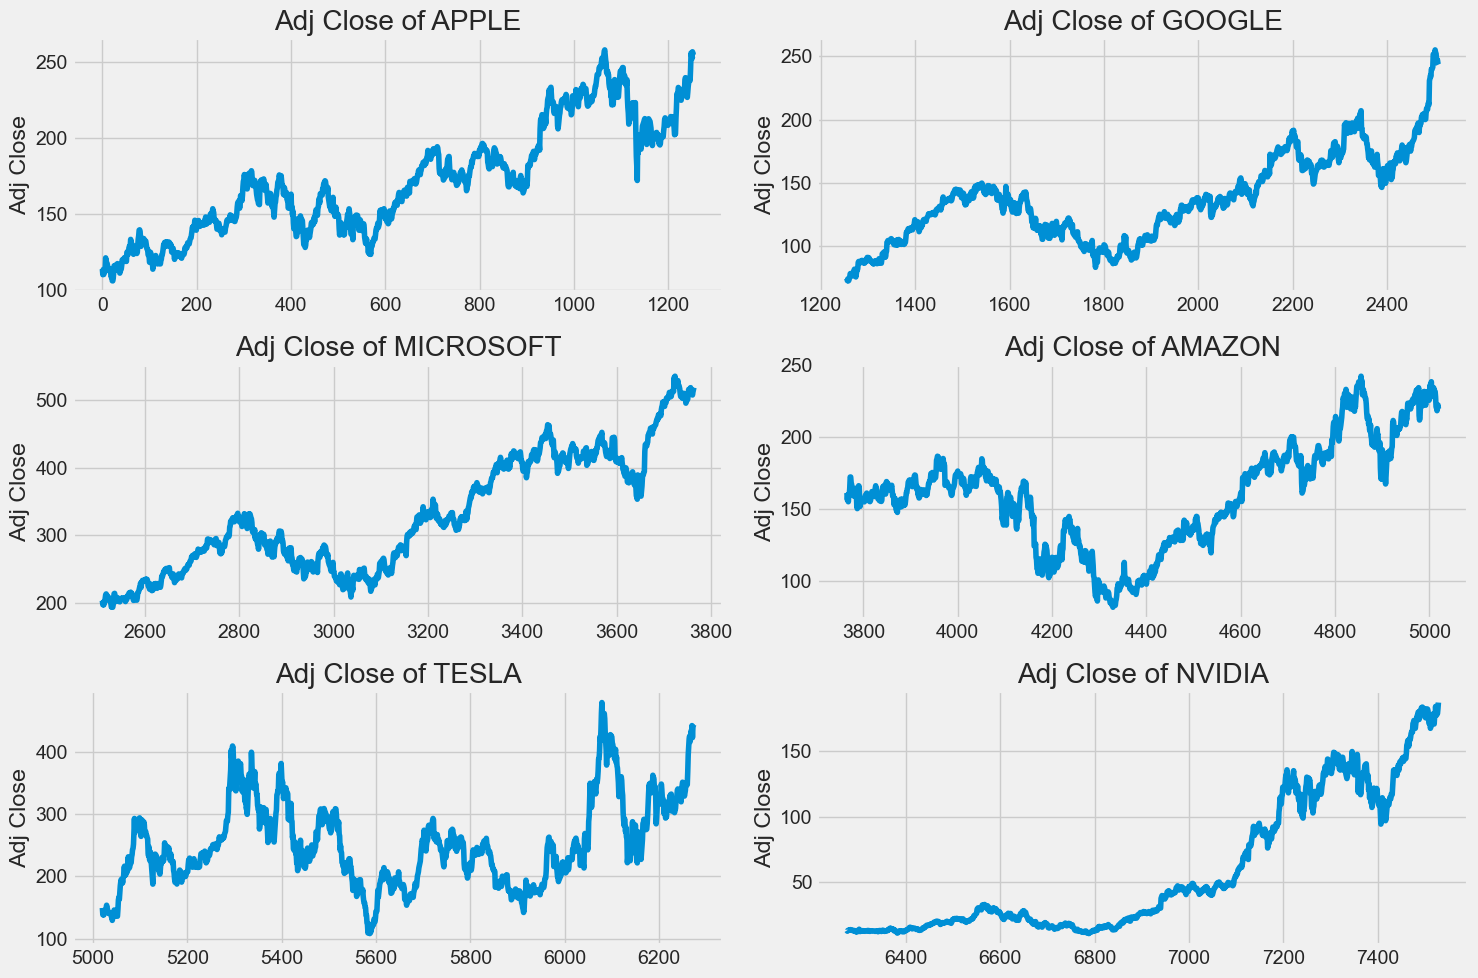

In [4]:
# See src/utils.py to find the definition
plotting_var(df,company_mapping,'Adj Close')


### Volume

Volume is the amount of an asset or security that changes hands over some period of time, often over the course of a day. For instance, the stock trading volume would refer to the number of shares of security traded between its daily open and close. Trading volume, and changes to volume over the course of time, are important inputs for technical traders.


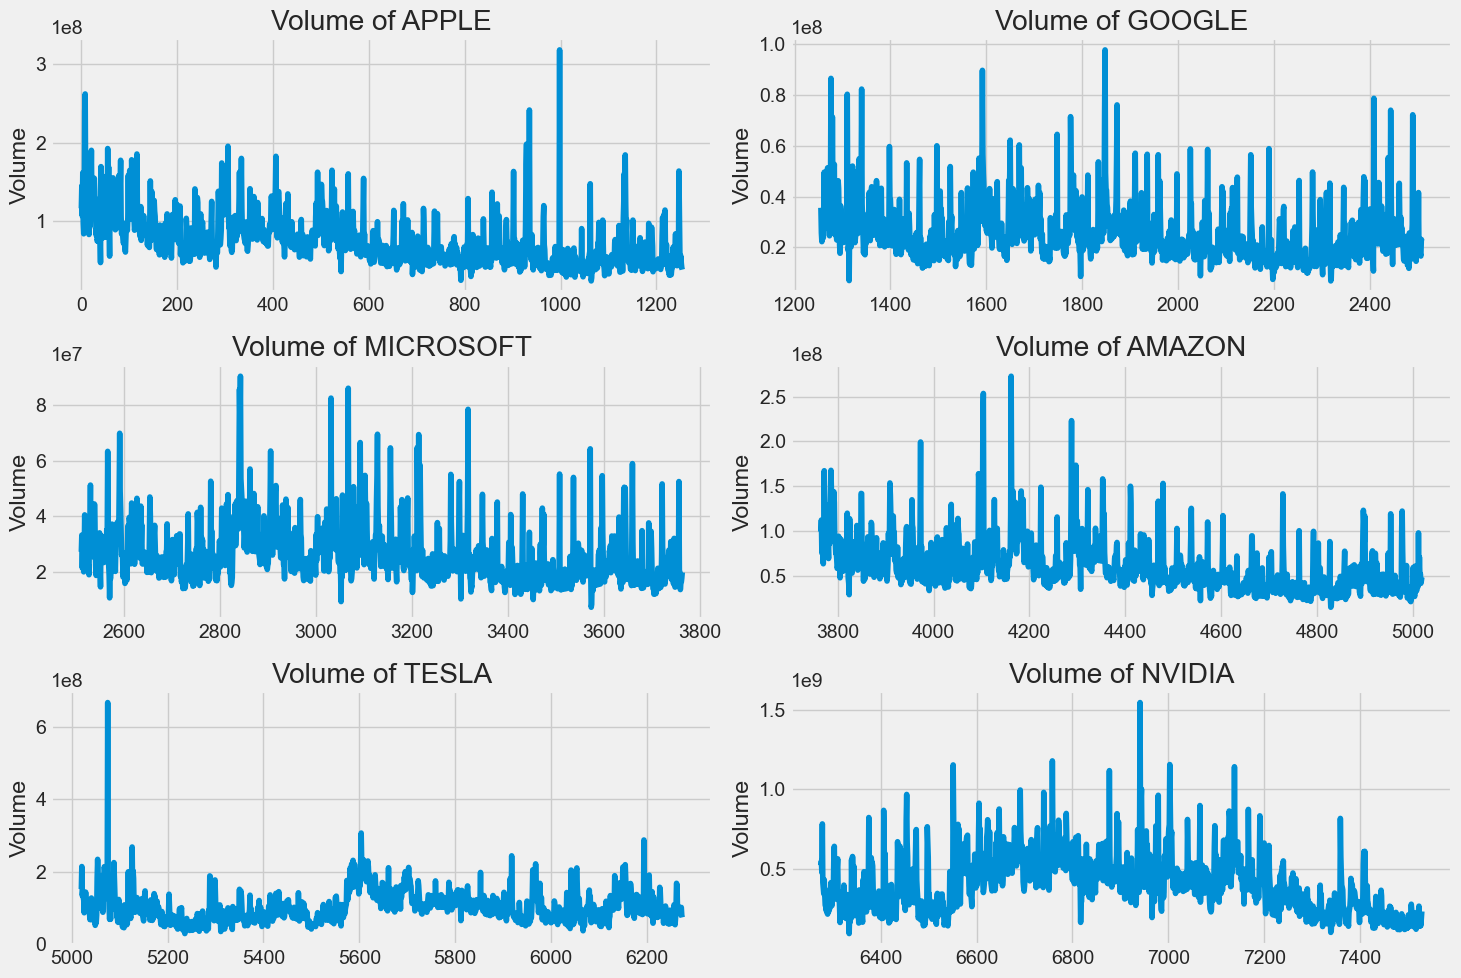

In [5]:
plotting_var(df,company_mapping,'Volume')


### Moving Averages

The moving average (MA) is a simple technical analysis tool that smooths out price data by creating a constantly updated average price. The average is taken over a specific period of time, like 10 days, 20 minutes, 30 weeks, or any time period the trader chooses.


Moving averages calculated successfully!
Available columns: ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'company_name', 'MA_10_days', 'MA_20_days', 'MA_50_days']


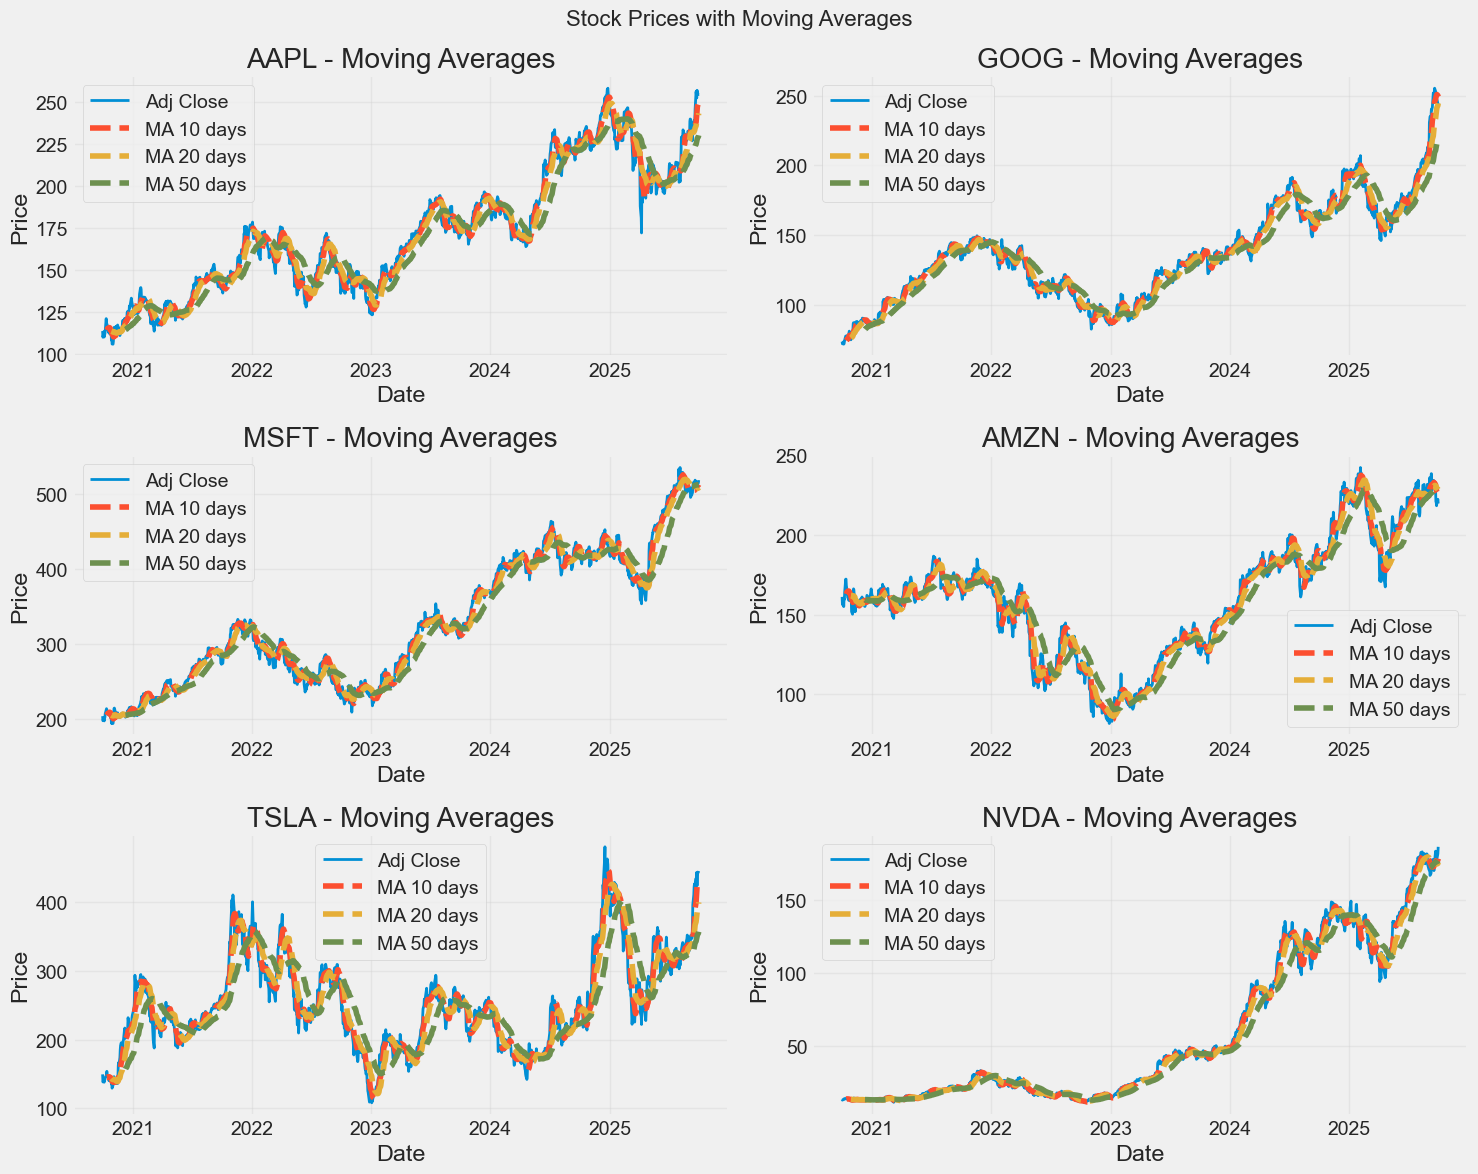

In [6]:
# Calculate moving averages using TA-Lib for better performance and accuracy
ma_periods = [10, 20, 50]

# Create a copy of the dataframe to add moving averages
df_with_ma = df.copy()

for period in ma_periods:
    column_name = f"MA_{period}_days"
    # Use TA-Lib's SMA (Simple Moving Average) function
    df_with_ma[column_name] = df.groupby('Ticker')['Adj Close'].transform(lambda x: talib.SMA(x.values, timeperiod=period))

print(f"Moving averages calculated successfully!")
print(f"Available columns: {list(df_with_ma.columns)}")

# Create subplots for each company showing moving averages
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
fig.suptitle('Stock Prices with Moving Averages', fontsize=16)


plot_positions = [(0,0), (0,1), (1,0), (1,1), (2,0),(2,1)]

for i, (company, pos) in enumerate(zip(company_mapping.keys(), plot_positions)):
    company_data = df_with_ma[df_with_ma['Ticker'] == company]
    ax = axes[pos[0], pos[1]]
    # Plot actual price and moving averages
    ax.plot(company_data['Date'], company_data['Adj Close'], label='Adj Close', linewidth=2)
    ax.plot(company_data['Date'], company_data['MA_10_days'], label='MA 10 days', linestyle='--')
    ax.plot(company_data['Date'], company_data['MA_20_days'], label='MA 20 days', linestyle='--')
    ax.plot(company_data['Date'], company_data['MA_50_days'], label='MA 50 days', linestyle='--')

    ax.set_title(f'{company} - Moving Averages')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Average Daily Returns

Let's take a look at the daily returns and what we can expect in the analysis. One of the important parts of these analyses is to conduct thorough investigations around the daily returns and the impact this might have on a certain period, especially for returns.


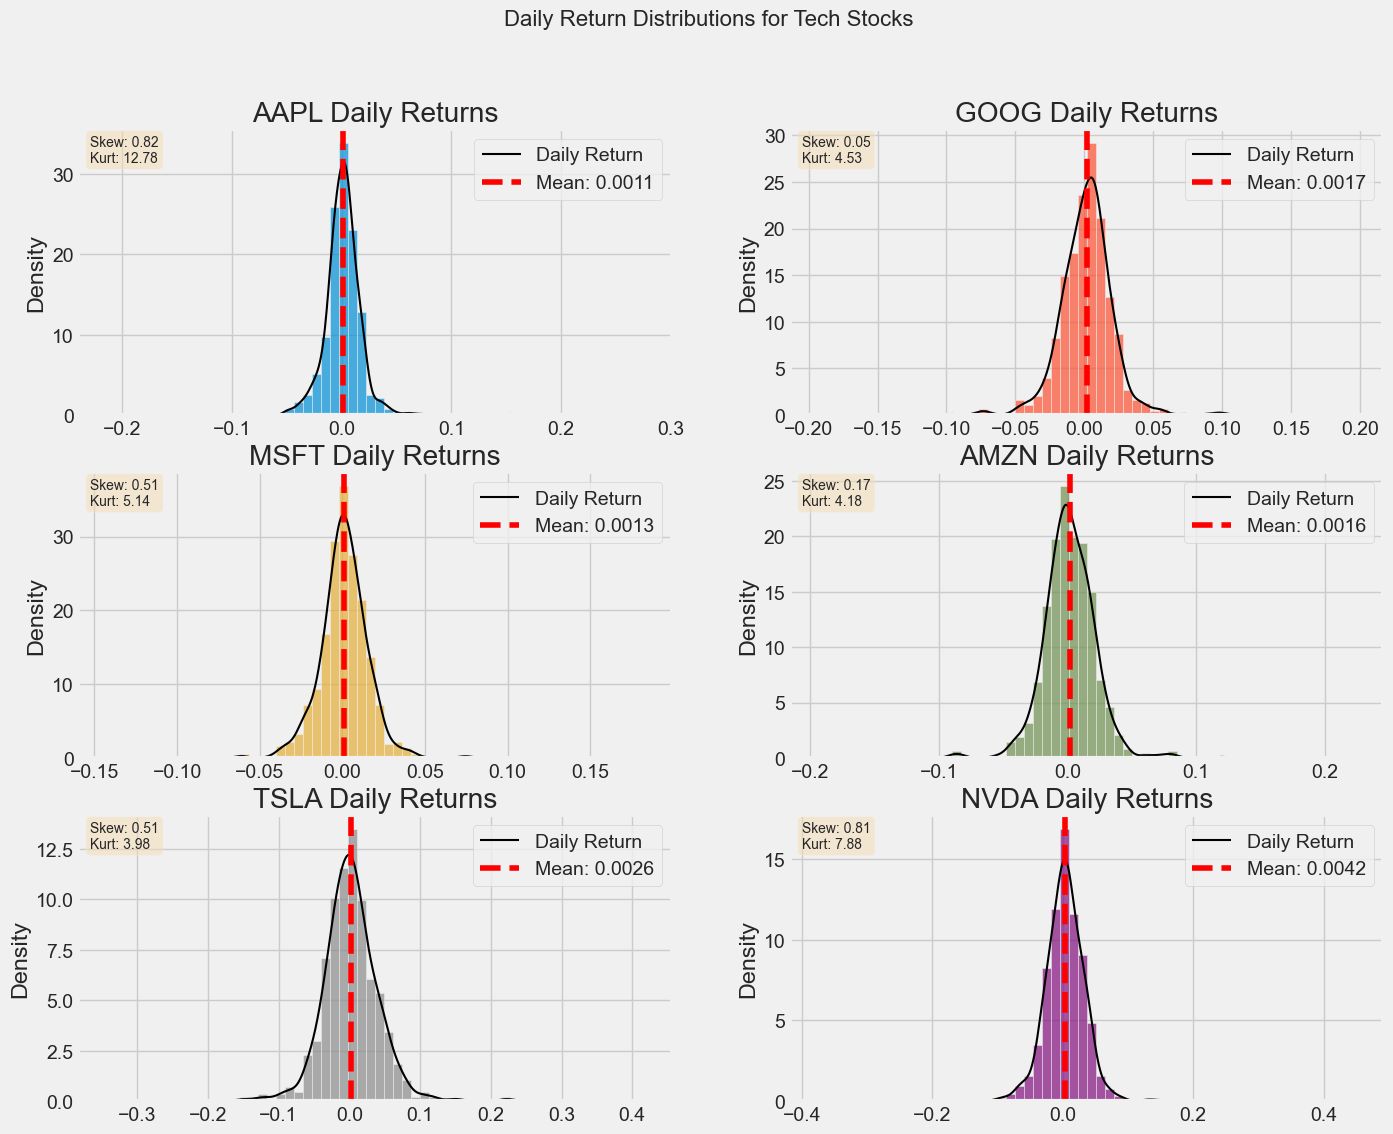

In [7]:
# We'll use pct_change to find the percent change for each day
# Calculate daily returns for each stock
start_date = '2023-01-01' 
end_date = '2025-12-31'

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
fig.suptitle('Daily Return Distributions for Tech Stocks', fontsize=16)

df_with_returns = df.copy()
df_with_returns['Daily Return'] = df.groupby('Ticker')['Adj Close'].pct_change()
# print(f"Daily returns calculated!")
# print(f"Sample daily returns: {df_with_returns['Daily Return'].head()}")

filtered_df = df_with_returns[(df_with_returns['Date'] >= start_date) & (df_with_returns['Date'] <= end_date)]

for i, (company, ax) in enumerate(zip(company_mapping.keys(), axes.flat)):
    # company_data = df_with_returns[df_with_returns['Ticker'] == company]['Daily Return'].dropna()
    company_data = filtered_df[filtered_df['Ticker'] == company]['Daily Return'].dropna()
    if company_data.empty:
        ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, ha='center')
        continue
    
    mean_return = company_data.mean()
    skew_val = skew(company_data)
    kurt_val = kurtosis(company_data)  # Excess kurtosis
    
    company_data.hist(ax=ax, bins=30, alpha=0.7, color=f'C{i}', density=True)
    company_data.plot(kind='kde', ax=ax, color='black', linewidth=1.5)
    ax.axvline(mean_return, color='red', linestyle='--', label=f'Mean: {mean_return:.4f}')
    ax.set_title(f'{company} Daily Returns')
    ax.legend()
    
    # Add skew and kurtosis as text
    ax.text(0.02, 0.98, f'Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))




## Data Preparation

### Correlation

Correlation is a statistic that measures the degree to which two variables move in relation to each other which has a value that must fall between -1.0 and +1.0. Correlation measures association, but doesn’t show if x causes y or vice versa — or if the association is caused by a third factor[1].

Now what if we wanted to analyze the returns of all the stocks in our list? Let's go ahead and build a DataFrame with all the ['Close'] columns for each of the stocks dataframes.


In [8]:
# Grab all the closing prices for the tech stock list into one DataFrame
closing_df = df.copy()[['Date','Ticker','Adj Close']].reset_index().pivot(index='Date', columns='Ticker', values='Adj Close')
# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.head()


Ticker,AAPL,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,,
2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-02,-0.032280,-0.029883,-0.021254,-0.029511,-0.040563,-0.073791
2020-10-05,0.030791,0.023744,0.018925,0.020321,0.044422,0.025513
2020-10-06,-0.028670,-0.031020,-0.021924,-0.021247,0.006890,-0.027485
2020-10-07,0.016967,0.030881,0.004713,0.019037,0.016562,0.027344


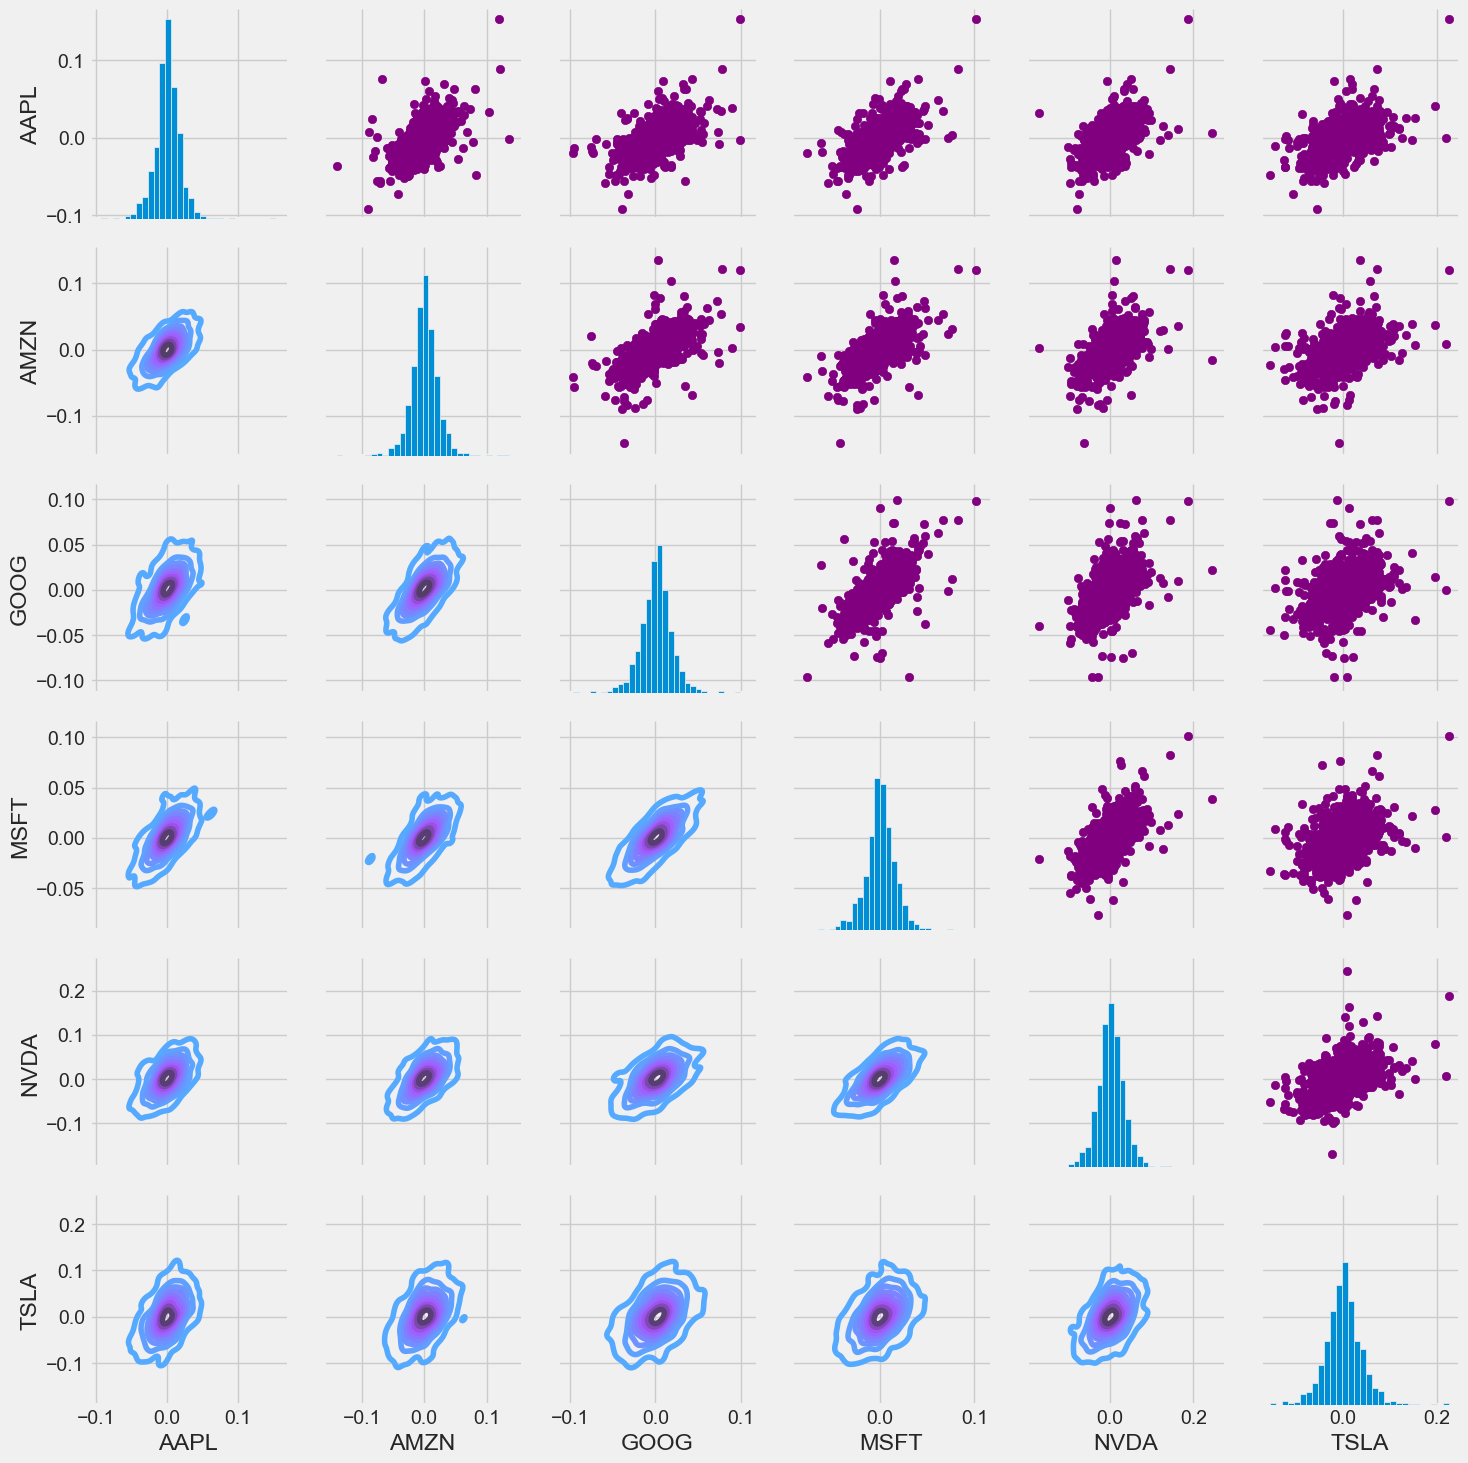

In [10]:
# # Comparing Google to itself should show a perfectly linear relationship
########################################################
# sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

#Contrast Google and Microsoft - A single sample jointplot
########################################################
# We'll use joinplot to compare the daily returns of Google and Microsoft
#sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

#Standard pairplot
########################################################
# We can simply call pairplot on our DataFrame for an automatic visual analysis 
# of all the comparisons
#sns.pairplot(tech_rets, kind='reg')

#Pairplot with seaborn - Custom definitions
########################################################
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())
# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')
# We can also define the lower triangle in the figure, inclufing the plot type (kde) 
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')
# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)


So now we can see that if two stocks are perfectly (and positivley) correlated with each other a linear relationship bewteen its daily return values should occur.

Seaborn and pandas make it very easy to repeat this comparison analysis for every possible combination of stocks in our technology stock ticker list. We can use `sns.pairplot()` to automatically create this plot


#### Correlation Heatmap

This correlation heatmap can help sum up the findings numerically in an easy, interpretable view about the effects.


Text(0.5, 1.0, 'Correlation of stock closing price')

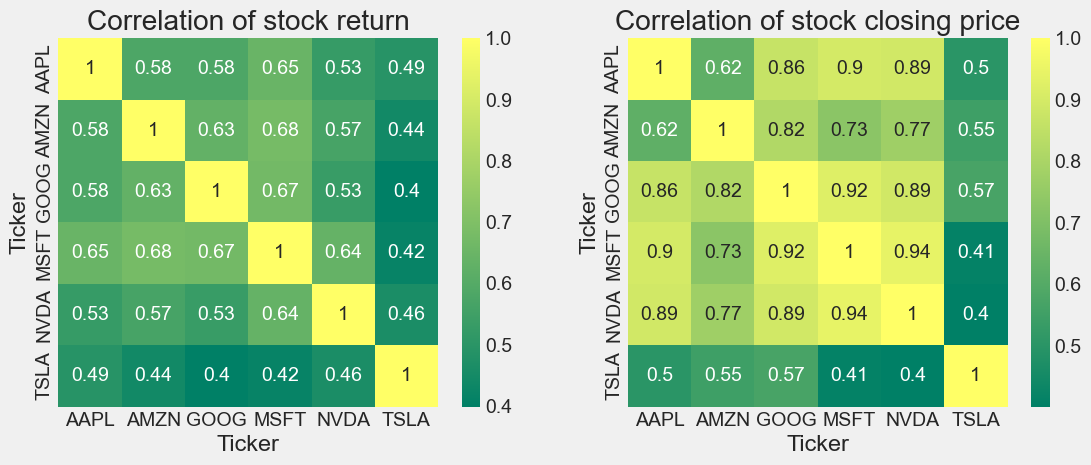

In [11]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')


As expect, the same stocks in the same industry have similar correlations directionally. So if one goes up, so does the other. The same is true as the prices come down and between the direction of the returns.

## Value at Risk (VaR)

Here, we are going to apply the simplest metric of Value at Risk:

- For each of the stocks, we get the average vs. the standard deviation of the daily returns

We can then compare this metric between the stocks and see which one is more volatile.


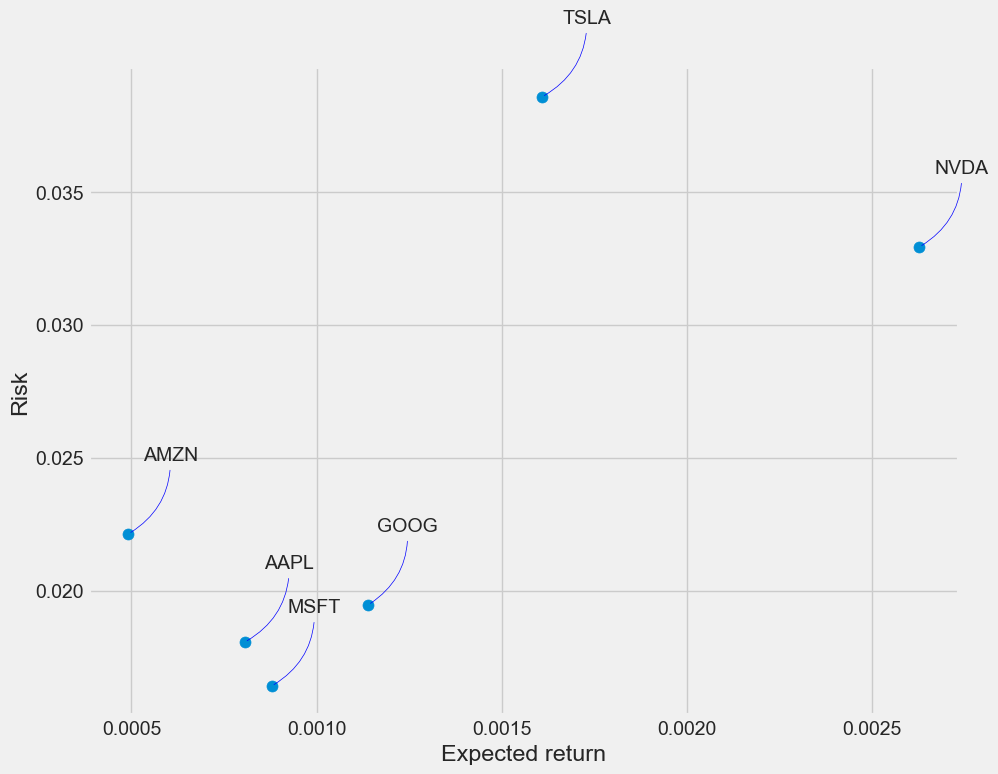

In [12]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))


## Data Analysis

We are going to begin to analyze the data a bit for a given stock, especially certain important statistical tests and metrics.


In [ ]:
#Let's define the variables
stock = 'AAPL'
# Get the stock data
stock_data = df[df['Ticker'] == stock]


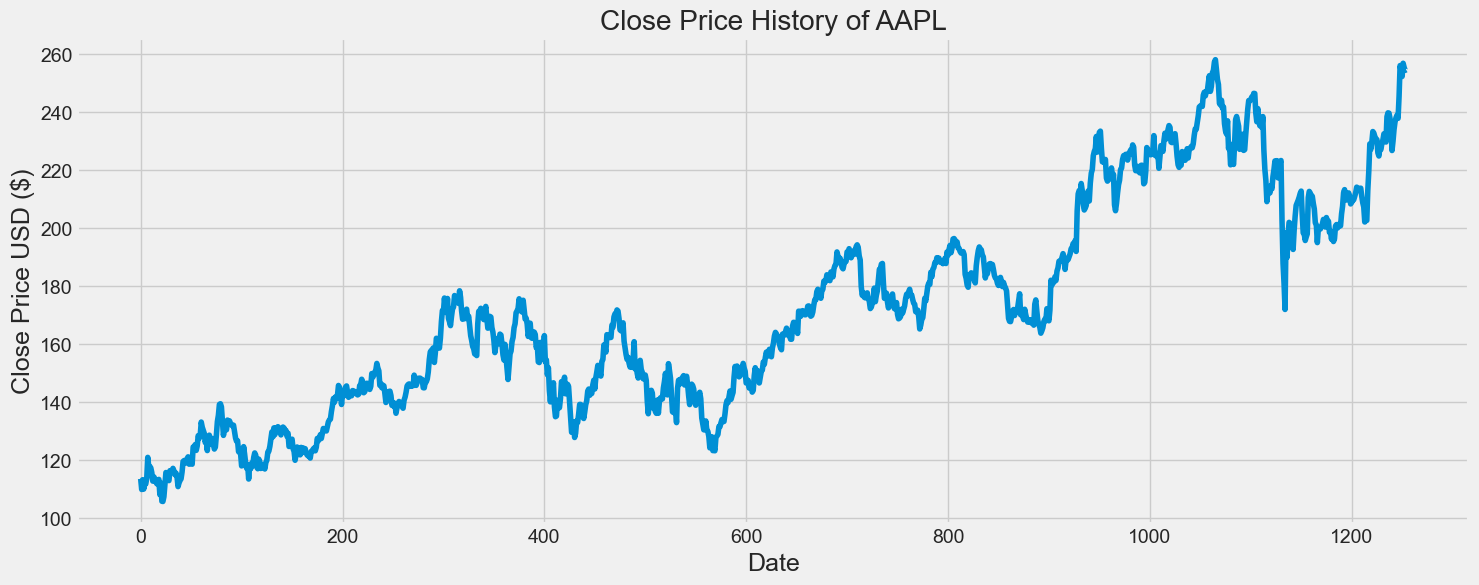

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History of ' + stock)
plt.plot(stock_data['Adj Close'])
plt.xlabel('Date', fontsize=18)

plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()


### Statistical Tests

Now, it's time to apply some statistical tests to the data to understand a bit more about the selected stock.
